In [1]:
# Install/import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape:", x_train.shape, y_train.shape)
print("Test data shape:", x_test.shape, y_test.shape)
print("Pixel value range:", x_train.min(), "-", x_train.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1301s 8us/step
Training data shape: (50000, 32, 32, 3) (50000, 1)
Test data shape: (10000, 32, 32, 3) (10000, 1)
Pixel value range: 0 - 255


/tmp/ipykernel_1210/1303889687.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(class_names, rotation=45)
/tmp/ipykernel_1210/1303889687.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(class_names, rotation=45)


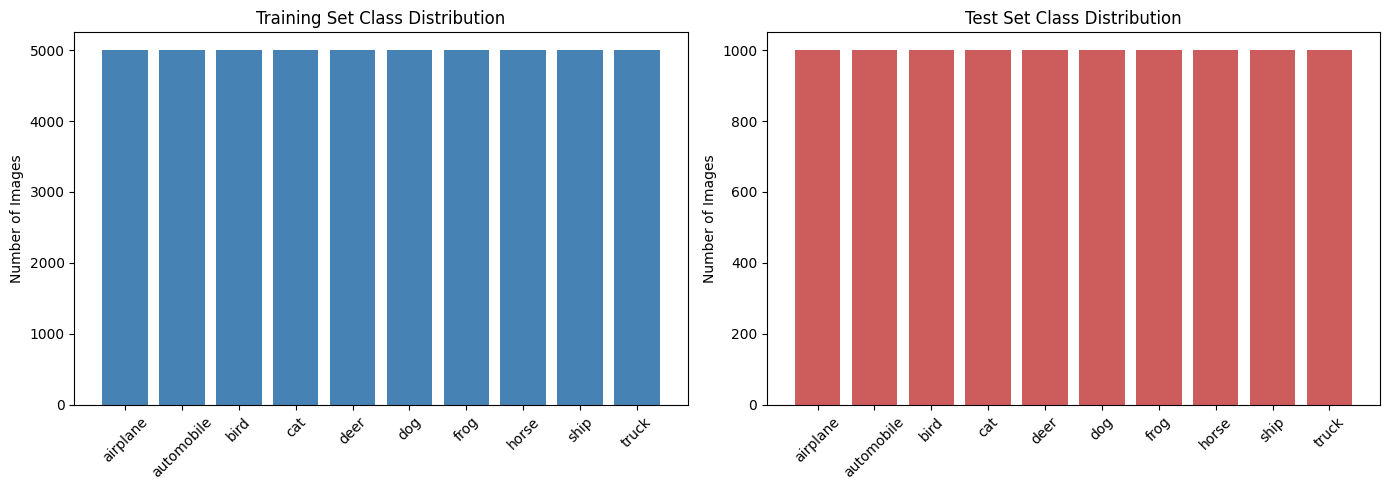

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_counts = np.bincount(y_train.flatten())
test_counts = np.bincount(y_test.flatten())

axes[0].bar(class_names, train_counts, color='steelblue')
axes[0].set_title("Training Set Class Distribution")
axes[0].set_xticklabels(class_names, rotation=45)
axes[0].set_ylabel("Number of Images")

axes[1].bar(class_names, test_counts, color='indianred')
axes[1].set_title("Test Set Class Distribution")
axes[1].set_xticklabels(class_names, rotation=45)
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()

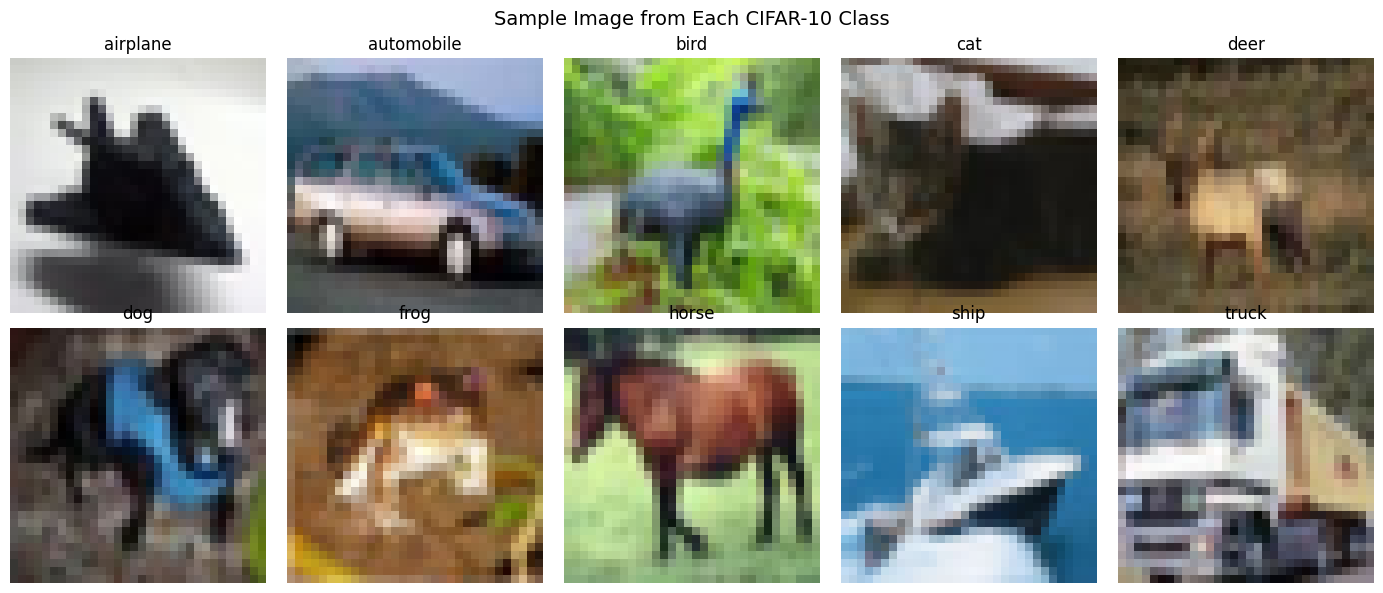

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train.flatten() == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(class_names[i])
    ax.axis('off')
plt.suptitle("Sample Image from Each CIFAR-10 Class", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Hold out a validation split from the training set
val_split = 0.1
val_size = int(len(x_train_norm) * val_split)

x_val = x_train_norm[:val_size]
y_val = y_train_cat[:val_size]
x_train_final = x_train_norm[val_size:]
y_train_final = y_train_cat[val_size:]

print("Final train shape:", x_train_final.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test_norm.shape)

Final train shape: (45000, 32, 32, 3)
Validation shape: (5000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [6]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1), padding='same',
                      activation='relu', input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool1'),

        layers.Conv2D(64, kernel_size=(3, 3), strides=(1, 1), padding='same',
                      activation='relu', name='conv2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool2'),

        layers.Conv2D(128, kernel_size=(3, 3), strides=(1, 1), padding='same',
                      activation='relu', name='conv3'),
        layers.MaxPooling2D(pool_size=(2, 2), name='pool3'),

        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='dense1'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = build_cnn()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
layer_param_summary = []
total_params = 0
for layer in model.layers:
    params = layer.count_params()
    total_params += params
    try:
        out_shape = layer.output.shape
    except AttributeError:
        out_shape = "N/A"
    layer_param_summary.append((layer.name, layer.__class__.__name__, out_shape, params))

print(f"{'Layer':<10}{'Type':<15}{'Output Shape':<20}{'Params':>12}")
print("-" * 60)
for name, ltype, shape, params in layer_param_summary:
    print(f"{name:<10}{ltype:<15}{str(shape):<20}{params:>12,}")
print("-" * 60)
print(f"Total trainable parameters: {total_params:,}")

Layer     Type           Output Shape              Params
------------------------------------------------------------
conv1     Conv2D         (None, 32, 32, 32)           896
pool1     MaxPooling2D   (None, 16, 16, 32)             0
conv2     Conv2D         (None, 16, 16, 64)        18,496
pool2     MaxPooling2D   (None, 8, 8, 64)               0
conv3     Conv2D         (None, 8, 8, 128)         73,856
pool3     MaxPooling2D   (None, 4, 4, 128)              0
flatten   Flatten        (None, 2048)                   0
dense1    Dense          (None, 128)              262,272
dropout   Dropout        (None, 128)                    0
output    Dense          (None, 10)                 1,290
------------------------------------------------------------
Total trainable parameters: 356,810


In [9]:
BATCH_SIZE = 64
EPOCHS = 20

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    x_train_final, y_train_final,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4017 - loss: 1.6316 - val_accuracy: 0.5600 - val_loss: 1.2446
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5640 - loss: 1.2308 - val_accuracy: 0.6430 - val_loss: 1.0243
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6318 - loss: 1.0527 - val_accuracy: 0.6848 - val_loss: 0.9067
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6752 - loss: 0.9305 - val_accuracy: 0.7100 - val_loss: 0.8421
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7014 - loss: 0.8569 - val_accuracy: 0.7202 - val_loss: 0.7925
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7276 - loss: 0.7836 - val_accuracy: 0.7166 - val_loss: 0.7960
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7478 - loss: 0.7209 - val_accuracy: 0.7490 - val_loss: 0.7369
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7628 - loss: 0.6741 - val_accuracy: 

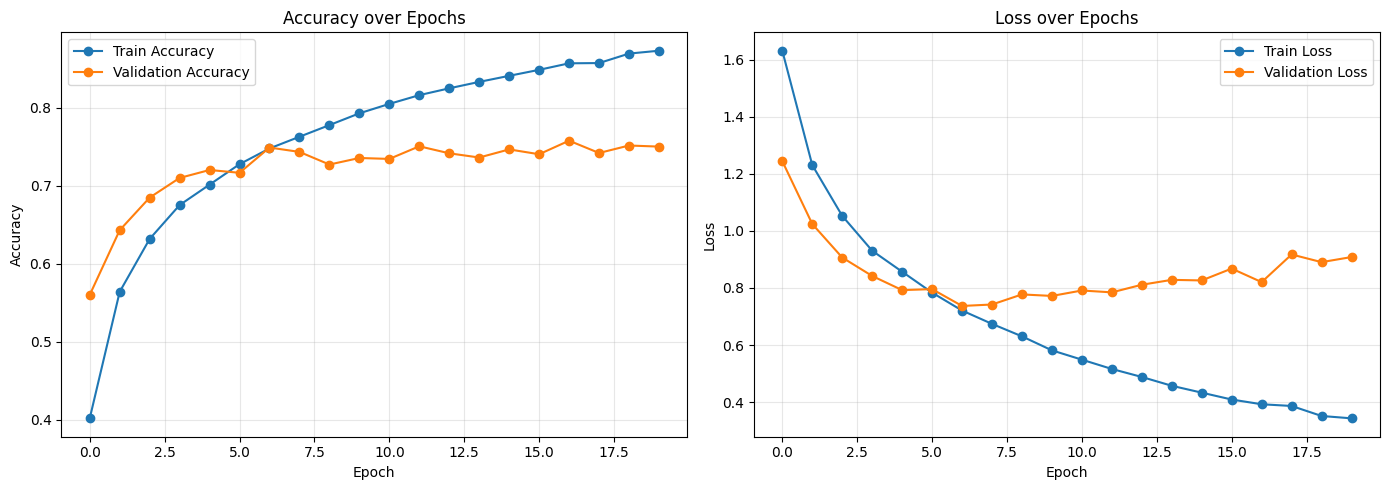

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_probs = model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"\nMacro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1-score:  {f1:.4f}")

Test Loss: 0.9960
Test Accuracy: 0.7444

Macro Precision: 0.7476
Macro Recall:    0.7444
Macro F1-score:  0.7452


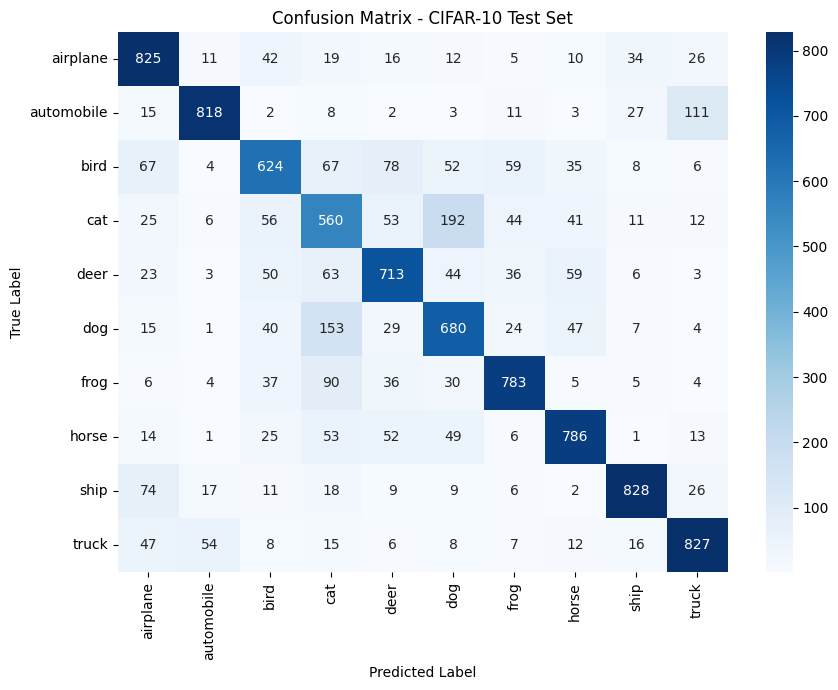

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CIFAR-10 Test Set')
plt.tight_layout()
plt.show()

In [13]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

    airplane       0.74      0.82      0.78      1000
  automobile       0.89      0.82      0.85      1000
        bird       0.70      0.62      0.66      1000
         cat       0.54      0.56      0.55      1000
        deer       0.72      0.71      0.72      1000
         dog       0.63      0.68      0.65      1000
        frog       0.80      0.78      0.79      1000
       horse       0.79      0.79      0.79      1000
        ship       0.88      0.83      0.85      1000
       truck       0.80      0.83      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.75     10000
weighted avg       0.75      0.74      0.75     10000



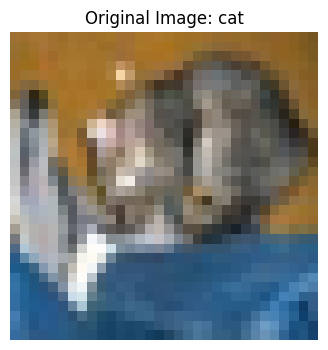

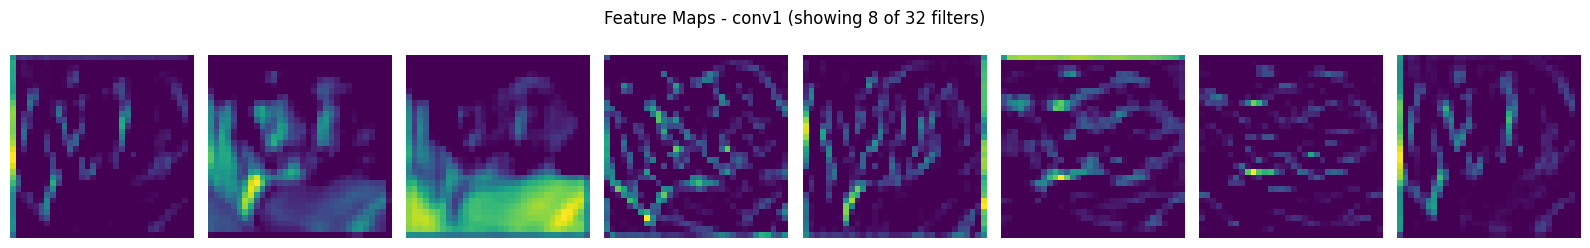

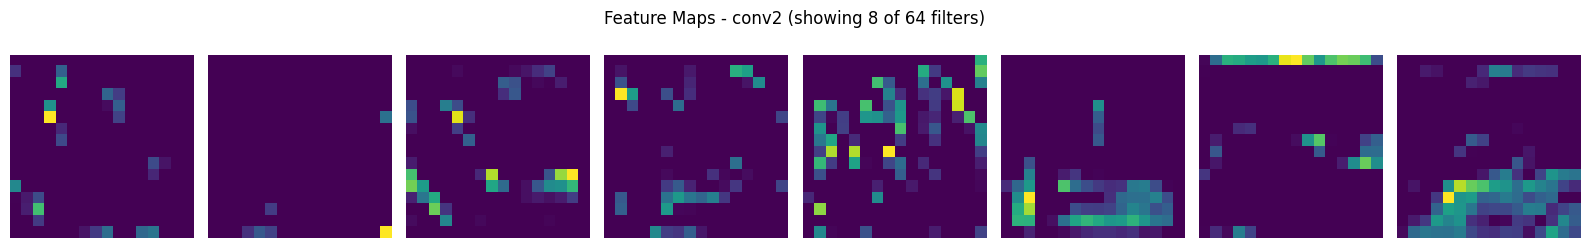

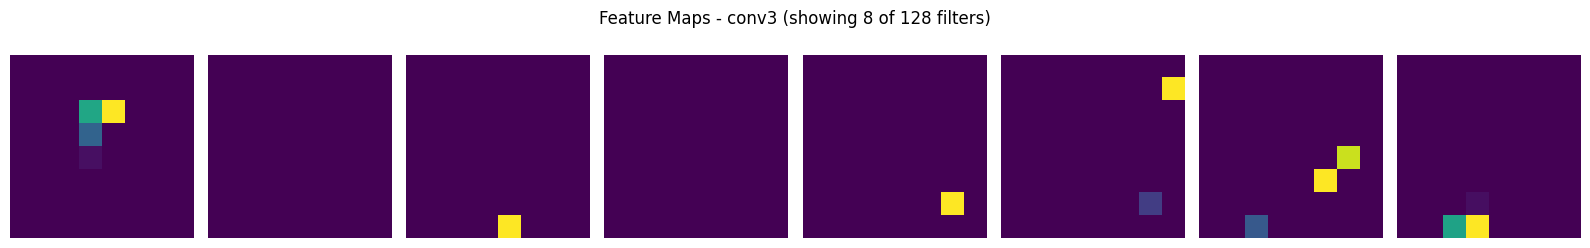

In [16]:
# Pick a sample test image
sample_img = x_test_norm[0:1]

plt.figure(figsize=(4, 4))
plt.imshow(x_test[0])
plt.title(f"Original Image: {class_names[y_test[0][0]]}")
plt.axis('off')
plt.show()

# Manually pass the image through each layer, capturing outputs of the conv layers
conv_layer_names = ['conv1', 'conv2', 'conv3']
x = sample_img
captured = {}
for layer in model.layers:
    x = layer(x)
    if layer.name in conv_layer_names:
        captured[layer.name] = x.numpy()

for layer_name in conv_layer_names:
    activation = captured[layer_name]
    num_filters = activation.shape[-1]
    n_display = min(8, num_filters)
    fig, axes = plt.subplots(1, n_display, figsize=(2 * n_display, 2.5))
    for i in range(n_display):
        axes[i].imshow(activation[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
    plt.suptitle(f"Feature Maps - {layer_name} (showing {n_display} of {num_filters} filters)")
    plt.tight_layout()
    plt.show()


--- Training with MAX pooling ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Max Pooling - Test Accuracy: 0.5499

--- Training with AVERAGE pooling ---
Average Pooling - Test Accuracy: 0.5466


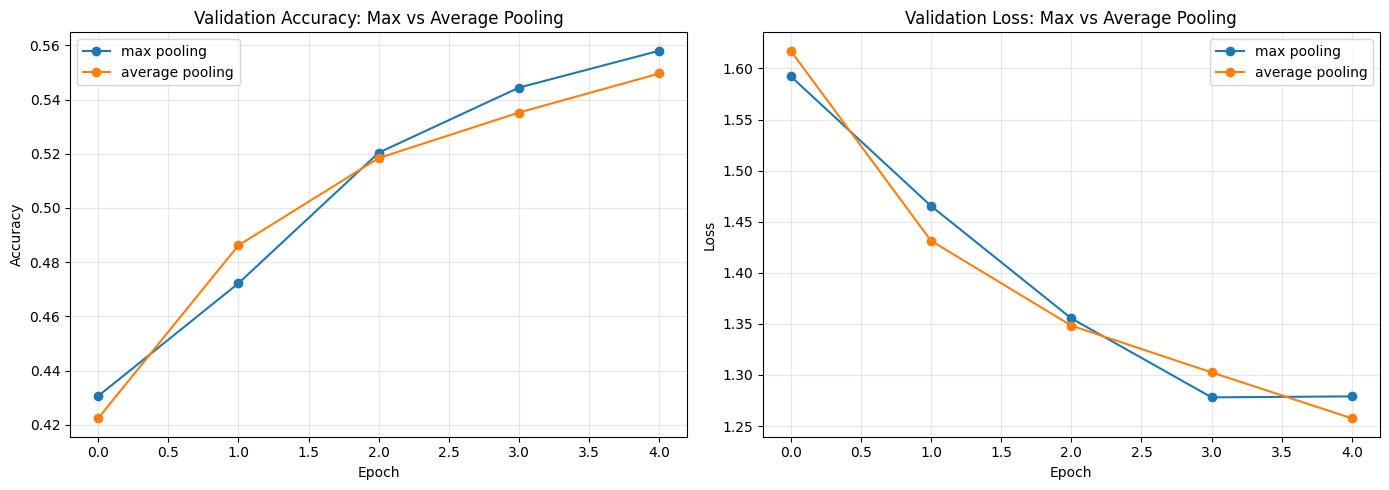


Final Test Accuracy Comparison:
  Max Pooling: 0.5499
  Average Pooling: 0.5466


In [17]:
def build_cnn_pooling(pooling_type='max', input_shape=(32, 32, 3), num_classes=10):
    PoolLayer = layers.MaxPooling2D if pooling_type == 'max' else layers.AveragePooling2D
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        PoolLayer((2, 2)),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        PoolLayer((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Use a subset for faster comparison
SUBSET = 10000
x_sub, y_sub = x_train_final[:SUBSET], y_train_final[:SUBSET]

pooling_results = {}
for pooling_type in ['max', 'average']:
    print(f"\n--- Training with {pooling_type.upper()} pooling ---")
    m = build_cnn_pooling(pooling_type)
    hist = m.fit(x_sub, y_sub, validation_data=(x_val, y_val),
                 batch_size=64, epochs=5, verbose=0)
    test_loss, test_acc = m.evaluate(x_test_norm, y_test_cat, verbose=0)
    pooling_results[pooling_type] = {'history': hist, 'test_acc': test_acc}
    print(f"{pooling_type.capitalize()} Pooling - Test Accuracy: {test_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for pooling_type, result in pooling_results.items():
    axes[0].plot(result['history'].history['val_accuracy'], marker='o', label=f'{pooling_type} pooling')
    axes[1].plot(result['history'].history['val_loss'], marker='o', label=f'{pooling_type} pooling')

axes[0].set_title('Validation Accuracy: Max vs Average Pooling')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Loss: Max vs Average Pooling')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal Test Accuracy Comparison:")
for pooling_type, result in pooling_results.items():
    print(f"  {pooling_type.capitalize()} Pooling: {result['test_acc']:.4f}")

In [18]:
def build_cnn_hp(kernel_size=(3,3), stride=(1,1), padding='same',
                  filters=(32, 64), optimizer='adam', input_shape=(32,32,3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(filters[0], kernel_size, strides=stride, padding=padding,
                      activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(filters[1], kernel_size, strides=stride, padding=padding,
                      activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

experiments = {
    'kernel_3x3':      dict(kernel_size=(3,3)),
    'kernel_5x5':      dict(kernel_size=(5,5)),
    'stride_1':        dict(stride=(1,1)),
    'stride_2':        dict(stride=(2,2)),
    'padding_same':    dict(padding='same'),
    'padding_valid':   dict(padding='valid'),
    'filters_32_64':   dict(filters=(32, 64)),
    'filters_64_128':  dict(filters=(64, 128)),
    'optimizer_adam':  dict(optimizer='adam'),
    'optimizer_sgd':   dict(optimizer='sgd'),
}

hp_results = {}
for exp_name, params in experiments.items():
    m = build_cnn_hp(**params)
    hist = m.fit(x_sub, y_sub, validation_data=(x_val, y_val),
                 batch_size=64, epochs=5, verbose=0)
    test_loss, test_acc = m.evaluate(x_test_norm, y_test_cat, verbose=0)
    hp_results[exp_name] = test_acc
    print(f"{exp_name:<18}: Test Accuracy = {test_acc:.4f}  |  Trainable Params = {m.count_params():,}")

kernel_3x3        : Test Accuracy = 0.5600  |  Trainable Params = 545,098
kernel_5x5        : Test Accuracy = 0.5620  |  Trainable Params = 579,402
stride_1          : Test Accuracy = 0.5472  |  Trainable Params = 545,098
stride_2          : Test Accuracy = 0.4941  |  Trainable Params = 53,578
padding_same      : Test Accuracy = 0.5616  |  Trainable Params = 545,098
padding_valid     : Test Accuracy = 0.5493  |  Trainable Params = 315,722
filters_32_64     : Test Accuracy = 0.5599  |  Trainable Params = 545,098
filters_64_128    : Test Accuracy = 0.5822  |  Trainable Params = 1,125,642
optimizer_adam    : Test Accuracy = 0.5568  |  Trainable Params = 545,098
optimizer_sgd     : Test Accuracy = 0.3381  |  Trainable Params = 545,098


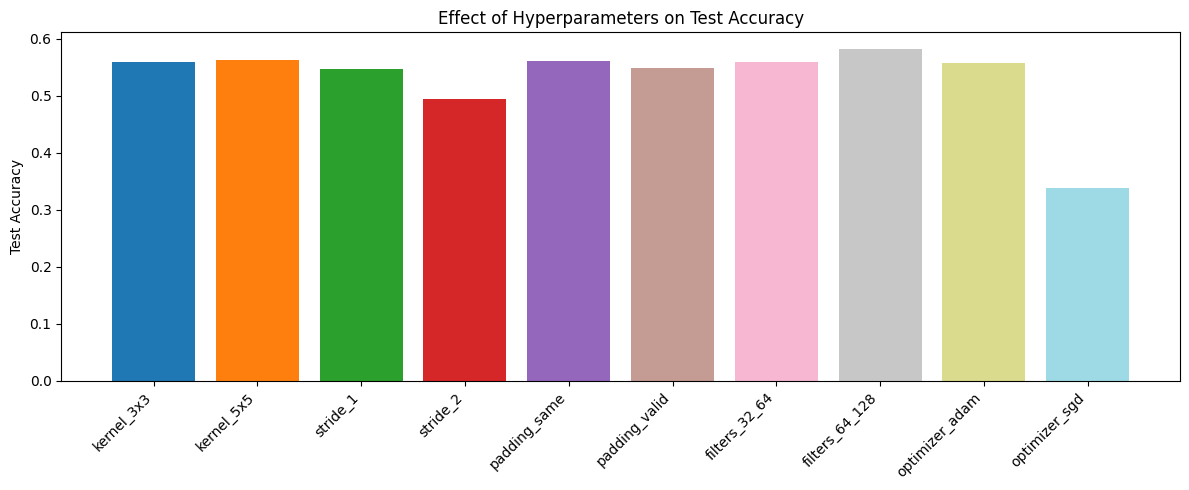

In [19]:
plt.figure(figsize=(12, 5))
names = list(hp_results.keys())
values = list(hp_results.values())
colors = plt.cm.tab20(np.linspace(0, 1, len(names)))
plt.bar(names, values, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Test Accuracy')
plt.title('Effect of Hyperparameters on Test Accuracy')
plt.tight_layout()
plt.show()

Batch size 32   : Test Accuracy = 0.5695
Batch size 64   : Test Accuracy = 0.5439
Batch size 128  : Test Accuracy = 0.5662


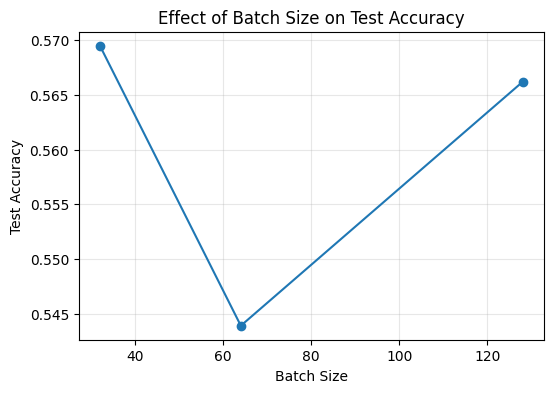

In [20]:
batch_sizes = [32, 64, 128]
bs_results = {}
for bs in batch_sizes:
    m = build_cnn_hp()
    hist = m.fit(x_sub, y_sub, validation_data=(x_val, y_val),
                 batch_size=bs, epochs=5, verbose=0)
    test_loss, test_acc = m.evaluate(x_test_norm, y_test_cat, verbose=0)
    bs_results[bs] = test_acc
    print(f"Batch size {bs:<5}: Test Accuracy = {test_acc:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(list(bs_results.keys()), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size')
plt.ylabel('Test Accuracy')
plt.title('Effect of Batch Size on Test Accuracy')
plt.grid(alpha=0.3)
plt.show()